# Point-E Preprocessing Pipeline: Phase 1 (2D Square Cropping)

Visually verify 2D transformations.

Point-E's image conditions (using CLIP) require standard square images. If we simply resize rectangular crops, the geometry will stretch, causing misalignment between the 2D view and the real 3D point cloud logic later.

So use square cropping that finds the pothole, forces the bounding box into a 1:1 ratio based on the largest dimension, adds an asphalt context margin, and applies zero-padding (black edges) if the crop hits the boundaries.

In [1]:
import sys
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import open3d as o3d

# Setup paths
candidate_roots = [d for d in Path.cwd().parents if d.name == "multimodal-pothole-detection"]
if len(candidate_roots) == 0:
    if Path.cwd().name == "multimodal-pothole-detection":
        code_root = Path.cwd()
    else:
        raise RuntimeError("Notebook needs to be run within the multimodal-pothole-detection project.")
else:
    code_root = candidate_roots[-1]

if str(code_root) not in sys.path:
    sys.path.insert(0, str(code_root))

scripts_root = code_root / "src" / "scripts"
print(f"Code Root: {code_root}")
if str(scripts_root) not in sys.path:
    sys.path.insert(0, str(scripts_root))

from pothole_geometry import load_yolo_mask
from point_e_pipeline_utils import get_square_bbox_from_mask, apply_square_crop, compute_leveled_point_cloud, format_point_e_tensor
from src.data.transforms.geometric import horizontal_flip

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Code Root: c:\Users\AdriBom\Documents\Repos\dgm-2026.1\projects\multimodal-pothole-detection


In [43]:
# 1. Configuration and Data Loading
CONTEXT_MARGIN_PX = 20  # Additional pixels to include around the pothole

dataset_root = code_root / "data" / "raw" / "PothRGDB" / "PUBLIC POTHOLE DATASET"
manifest = pd.read_csv(code_root / "data" / "interim" / "pothrgbd_manifest.csv")
valid_samples = manifest[manifest["status"] == "ok"].reset_index(drop=True)

# Select sample to visualize
sample_idx = 607
row = valid_samples.iloc[sample_idx]
print(f"Loaded Sample ID: {row['sample_id']}")

rgb_path = dataset_root / row["image_path"]
mask_path = dataset_root / row["label_path"]

# Load
rgb_img = cv2.cvtColor(cv2.imread(str(rgb_path)), cv2.COLOR_BGR2RGB)
mask_img = load_yolo_mask(mask_path, image_shape=rgb_img.shape[:2])

Loaded Sample ID: 20250305_100402


## Visual Verification: Original vs Safe Square Crop
We want to prove that our utility strictly preserves aspect ratios instead of stretching the image.

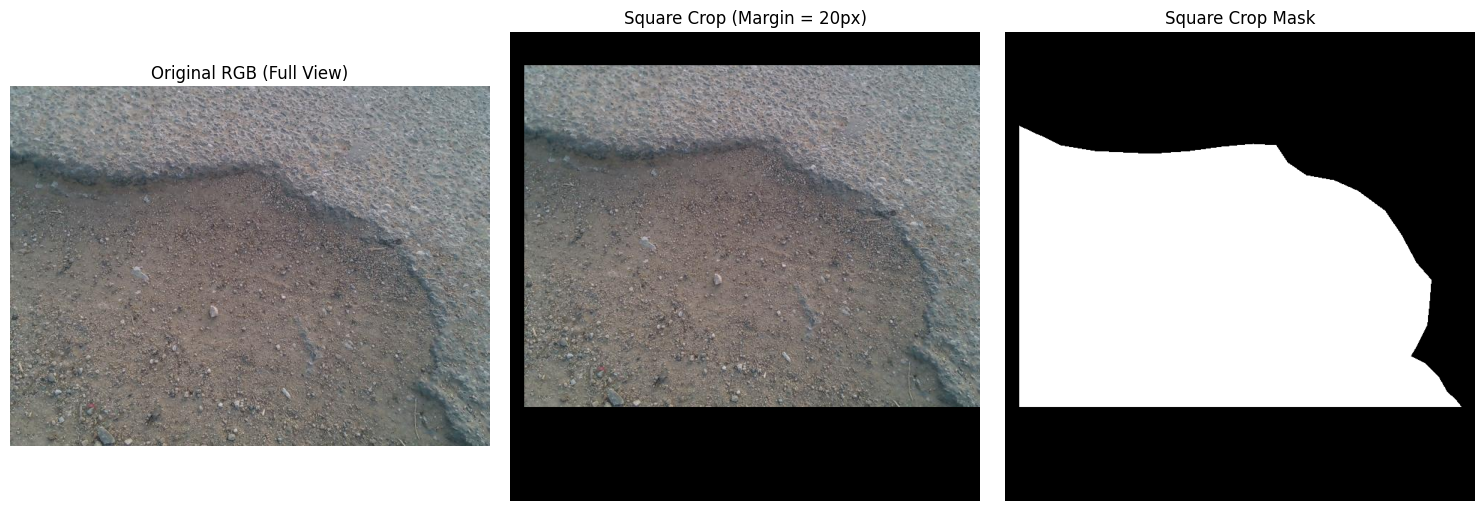

Original Shape: (480, 640, 3)
Cropped Shape: (660, 660, 3)


In [44]:
# Calculate the fixed square coordinates from the mask
square_bbox = get_square_bbox_from_mask(mask_img, margin_px=CONTEXT_MARGIN_PX)

# Apply that exact square bbox to both the RGB and the Mask
rgb_crop = apply_square_crop(rgb_img, square_bbox)
mask_crop = apply_square_crop(mask_img, square_bbox)

# Display Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb_img)
axes[0].set_title("Original RGB (Full View)")
axes[0].axis("off")

axes[1].imshow(rgb_crop)
axes[1].set_title(f"Square Crop (Margin = {CONTEXT_MARGIN_PX}px)")
axes[1].axis("off")

axes[2].imshow(mask_crop, cmap='gray')
axes[2].set_title("Square Crop Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Original Shape: {rgb_img.shape}")
print(f"Cropped Shape: {rgb_crop.shape}")

## Padding Strategy Investigation
When the square bounding box exceeds the image limits (common for potholes near the edge), we must fill the "missing" area to maintain a 1:1 aspect ratio for Point-E. 

Below we compare 4 strategies to avoid the "black bar" effect, which can be detrimental to the model's feature extraction:
1. **Black (Current):** Zero-padding.
2. **Reflect 101:** Mirrors the edge texture.
3. **Replicate:** Extends the last pixel (gradient-like).
4. **Inpaint (Telea):** Synthesizes texture to fill the gap naturally.

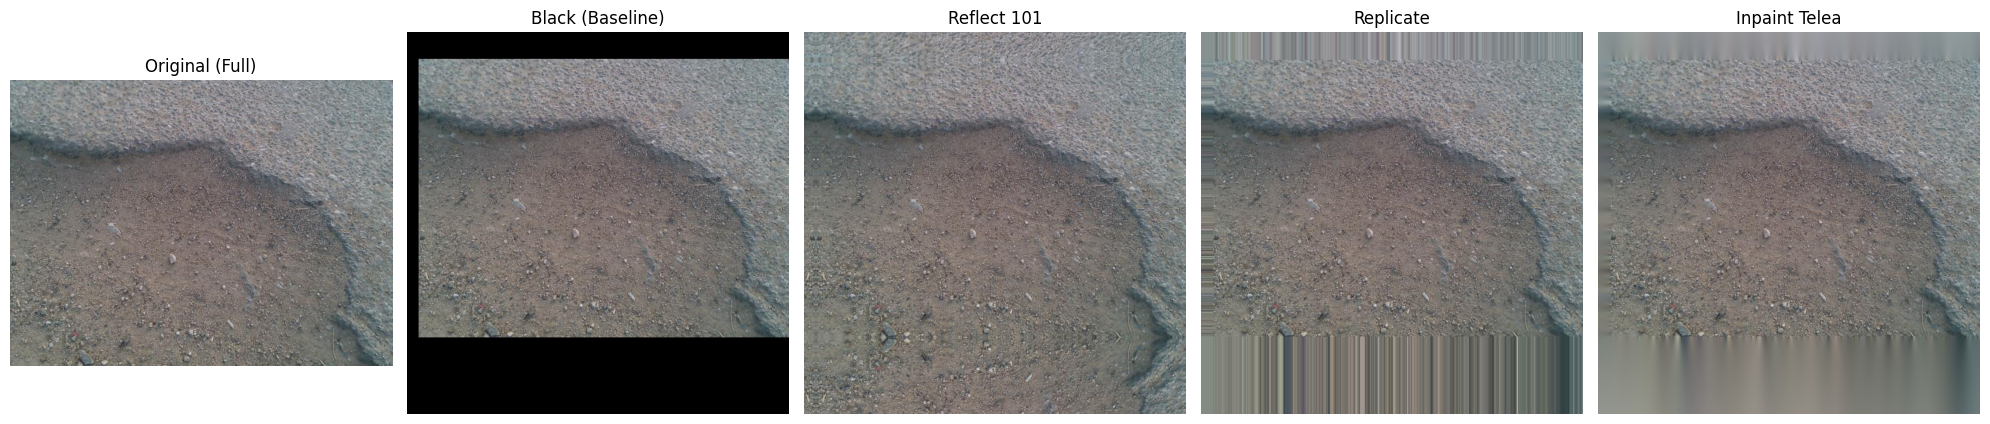

Padding detected (200px total). Comparison is relevant.


In [45]:
def compare_padding_strategies(image, bbox):
    y_min, y_max, x_min, x_max = bbox
    h, w = image.shape[:2]
    
    # Calculate padding amounts
    pad_top = max(0, -y_min)
    pad_bottom = max(0, y_max - h)
    pad_left = max(0, -x_min)
    pad_right = max(0, x_max - w)
    
    # 1. Black (Baseline - reuse existing utility)
    crop_black = apply_square_crop(image, bbox)
    
    # 2. Reflect 101
    img_padded_reflect = cv2.copyMakeBorder(image, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_REFLECT_101)
    crop_reflect = img_padded_reflect[y_min+pad_top : y_max+pad_top, x_min+pad_left : x_max+pad_left]
    
    # 3. Replicate
    img_padded_rep = cv2.copyMakeBorder(image, pad_top, pad_bottom, pad_left, pad_right, cv2.BORDER_REPLICATE)
    crop_replicate = img_padded_rep[y_min+pad_top : y_max+pad_top, x_min+pad_left : x_max+pad_left]
    
    # 4. Inpaint (Telea)
    # Generate mask for missing pixels
    mask = np.zeros((crop_black.shape[0], crop_black.shape[1]), dtype=np.uint8)
    src_y_min, src_y_max = max(0, y_min), min(h, y_max)
    src_x_min, src_x_max = max(0, x_min), min(w, x_max)
    dst_y_min, dst_y_max = src_y_min - y_min, src_y_max - y_min
    dst_x_min, dst_x_max = src_x_min - x_min, src_x_max - x_min
    
    mask.fill(255)
    mask[dst_y_min:dst_y_max, dst_x_min:dst_x_max] = 0
    crop_inpaint = cv2.inpaint(crop_black, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    
    return {
        "Black (Baseline)": crop_black,
        "Reflect 101": crop_reflect,
        "Replicate": crop_replicate,
        "Inpaint Telea": crop_inpaint
    }

# Execute comparison
strategies = compare_padding_strategies(rgb_img, square_bbox)

# Visualization
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(rgb_img)
axes[0].set_title("Original (Full)")
axes[0].axis("off")

for i, (name, img) in enumerate(strategies.items(), 1):
    axes[i].imshow(img)
    axes[i].set_title(name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Print if padding was actually needed for this sample
pad_sum = sum([max(0, -square_bbox[0]), max(0, square_bbox[1] - rgb_img.shape[0]), 
               max(0, -square_bbox[2]), max(0, square_bbox[3] - rgb_img.shape[1])])
if pad_sum == 0:
    print("WARNING: This sample does not require padding. Try another sample_idx (e.g., near boundaries) to see the difference.")
else:
    print(f"Padding detected ({pad_sum}px total). Comparison is relevant.")

## 3D Geometry and Point-E Tensor Standardization
Now we extract the 3D points *only* from the unpadded valid region of our crop.
We ensure that the asphalt is completely leveled using RANSAC.
Finally, we apply Open3D's **Farthest Point Sampling** to grab exactly 1024 points, and uniformly scale $X, Y, Z$ into the rigid $[-1, 1]$ bounding box required by Point-E.

In [28]:
depth_path = dataset_root / row["depth_path"]
depth_img = np.load(depth_path)  # CRITICAL: `.npy` preserves exact millimeter physics

# Intrinsics
fx, fy = 460.0, 460.0
cx, cy = rgb_img.shape[1] / 2.0, rgb_img.shape[0] / 2.0

# 1. 3D Extraction + RANSAC Leveling
points_3d, colors_3d = compute_leveled_point_cloud(
    rgb_img=rgb_img,
    depth_img=depth_img,
    mask_img=mask_img,
    square_bbox=square_bbox,
    fx=fx, fy=fy, cx=cx, cy=cy
)
print(f"Raw Crop yielded {points_3d.shape[0]} points.")

# 2. Strict Point-E Sampling & Normalization
tensor_6d, scale_factor = format_point_e_tensor(points_3d, colors_3d, num_points=1024)

print("\n--- Point-E Ready Tensor ---")
print(f"Shape: {tensor_6d.shape}")
print(f"Global Scale Factor saved: {scale_factor:.2f} mm")

# Verify constraints
spatial = tensor_6d[:, :3]
color = tensor_6d[:, 3:]

print(f"\nConstraint Check (MUST be between -1.0 and 1.0):")
print(f"X range: {spatial[:, 0].min():.2f} to {spatial[:, 0].max():.2f}")
print(f"Y range: {spatial[:, 1].min():.2f} to {spatial[:, 1].max():.2f}")
print(f"Z range: {spatial[:, 2].min():.2f} to {spatial[:, 2].max():.2f}")
print(f"Color ranges: R({color[:, 0].min():.2f} to {color[:, 0].max():.2f}), G({color[:, 1].min():.2f} to {color[:, 1].max():.2f})")

Raw Crop yielded 246767 points.

--- Point-E Ready Tensor ---
Shape: (1024, 6)
Global Scale Factor saved: 329.24 mm

Constraint Check (MUST be between -1.0 and 1.0):
X range: -0.98 to 1.00
Y range: -0.92 to 0.91
Z range: -0.10 to 0.06
Color ranges: R(-0.69 to 0.70), G(-0.65 to 0.69)


In [29]:
# Visualize the 3D result before and after the Point-E standardization step

# Recreate the original Open3D point cloud for comparison
pcd_raw = o3d.geometry.PointCloud()
pcd_raw.points = o3d.utility.Vector3dVector(points_3d)
pcd_raw.colors = o3d.utility.Vector3dVector(np.clip(colors_3d, 0.0, 1.0))

print("Original 3D point cloud (before leveling and Point-E normalization)")
o3d.visualization.draw_geometries([pcd_raw])

# Recreate the resulting AI Ready Tensor for visualization
pcd_ai = o3d.geometry.PointCloud()
pcd_ai.points = o3d.utility.Vector3dVector(spatial)
# Bring colors back from [-1, 1] to [0, 1] purely for open3d plotting
pcd_ai.colors = o3d.utility.Vector3dVector((color + 1.0) / 2.0)

print("Point-E ready 3D tensor (after leveling and normalization)")
# The view should look like a correctly angled pothole crater composed of exactly 1024 dots
o3d.visualization.draw_geometries([pcd_ai])

Original 3D point cloud (before leveling and Point-E normalization)
Point-E ready 3D tensor (after leveling and normalization)


In [ ]:
# Visualize the 3D flip correction on the Point-E ready tensor

# Keep a copy of the original tensor before any geometric augmentation
original_tensor_6d = tensor_6d.copy()

# Apply the paired horizontal flip in memory only
_, flipped_tensor_6d = horizontal_flip(rgb_img, original_tensor_6d)

original_spatial = original_tensor_6d[:, :3]
original_color = original_tensor_6d[:, 3:]
flipped_spatial = flipped_tensor_6d[:, :3]
flipped_color = flipped_tensor_6d[:, 3:]

print("Original Point-E tensor (before horizontal flip correction)")
pcd_original = o3d.geometry.PointCloud()
pcd_original.points = o3d.utility.Vector3dVector(original_spatial)
pcd_original.colors = o3d.utility.Vector3dVector((original_color + 1.0) / 2.0)
o3d.visualization.draw_geometries([pcd_original])

print("Flipped Point-E tensor (after horizontal flip correction)")
pcd_flipped = o3d.geometry.PointCloud()
pcd_flipped.points = o3d.utility.Vector3dVector(flipped_spatial)
pcd_flipped.colors = o3d.utility.Vector3dVector((flipped_color + 1.0) / 2.0)
o3d.visualization.draw_geometries([pcd_flipped])

print(f"Original X range: {original_spatial[:, 0].min():.2f} to {original_spatial[:, 0].max():.2f}")
print(f"Flipped X range: {flipped_spatial[:, 0].min():.2f} to {flipped_spatial[:, 0].max():.2f}")
print("If the correction is right, the flipped range should mirror the original one around X = 0.")